In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [7]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))

100.0%
100.0%
100.0%
100.0%


Training images: 60000
Testing images: 10000


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


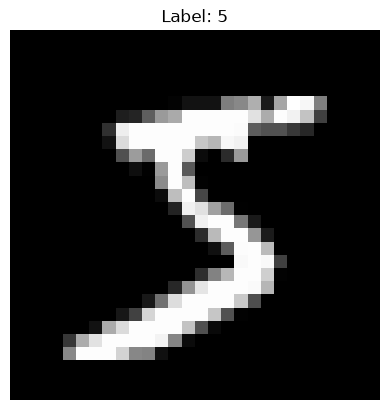

In [9]:
image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [12]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = CNN().to(device)

print(model)

CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [13]:
model = CNN().to(device)

model.load_state_dict(
    torch.load("handwritten_character_cnn.pth", map_location=device)
)

model.eval()

print("Trained model loaded successfully.")

Trained model loaded successfully.


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer ready.")

Loss function and optimizer ready.


In [13]:
epochs = 2

for epoch in range(epochs):
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    average_loss = running_loss / len(train_loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}], "
        f"Loss: {average_loss:.4f}"
    )

Epoch [1/2], Loss: 0.2298
Epoch [2/2], Loss: 0.0678


In [14]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.69%


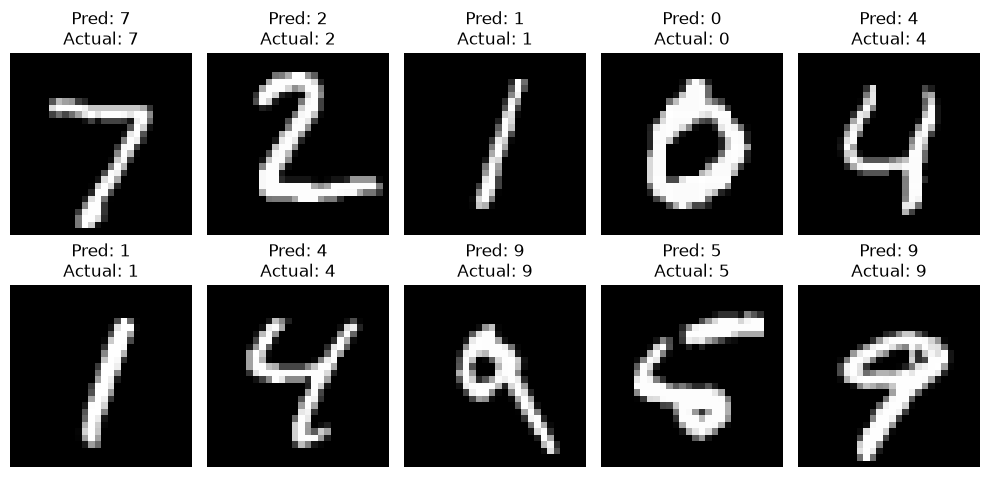

In [15]:
model.eval()

images, labels = next(iter(test_loader))

images = images.to(device)

with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1)

images = images.cpu()
predictions = predictions.cpu()
labels = labels.cpu()

plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Pred: {predictions[i].item()}\nActual: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
torch.save(model.state_dict(), "handwritten_character_cnn.pth")

print("Model saved successfully.")

Model saved successfully.


  Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.26.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp314-cp314-win_amd64.whl (8.4 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.26.0-py3-none-any.whl (474 kB)
Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl (37.4 MB)
Using cached threadpoolctl-3.7.0-py3-none-any.whl (26 kB)

   ---------------------------------------- 0/6 [threadpoolctl]
   ---------------------------------------- 0/6 [threadpoolctl]
   ------ --------------------------------- 1/6 [scipy]
   ------ --------------------------------- 1/6 [sc


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


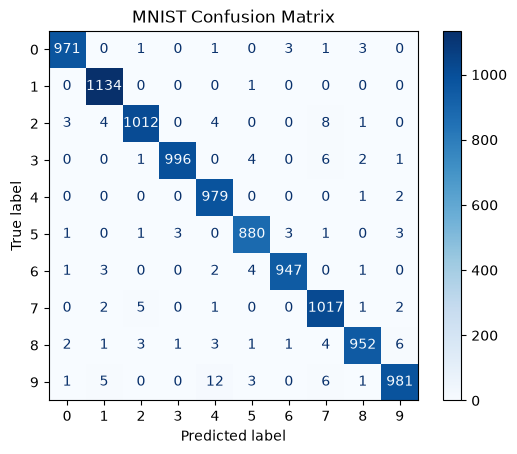

In [18]:
%pip install scikit-learn
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_predictions = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=range(10)
)

disp.plot(cmap="Blues")
plt.title("MNIST Confusion Matrix")
plt.show()

In [19]:
with open("results.txt", "w") as f:
    f.write(f"Test Accuracy: {accuracy:.2f}%\n")

print("Results saved.")

Results saved.


In [20]:
%pip install pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Predicted digit: 7


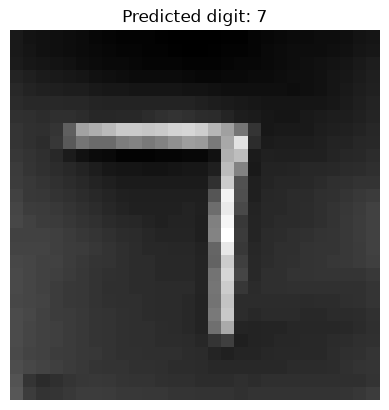

In [15]:
from PIL import Image, ImageOps
import torch
import matplotlib.pyplot as plt

# Load your handwritten digit
image = Image.open("second-image.jpg").convert("L")

# Prepare the image like MNIST
image = ImageOps.invert(image)
image = image.resize((28, 28))

# Convert image to a tensor
image_tensor = transforms.ToTensor()(image)

# Add batch dimension
image_tensor = image_tensor.unsqueeze(0).to(device)

# Make prediction
model.eval()

with torch.no_grad():
    output = model(image_tensor)
    prediction = output.argmax(dim=1).item()

print("Predicted digit:", prediction)

# Show the image
plt.imshow(image, cmap="gray")
plt.title(f"Predicted digit: {prediction}")
plt.axis("off")
plt.show()